[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skarma91/logicmojo-ai-july-2026/blob/main/modules/module-2-ml-dl-essentials/milestone-assignment/assignment.ipynb)

# Module 2 milestone

Build the whole training workflow end to end on a real tabular dataset. See `README.md` for the full brief. Fill in each step and run it top to bottom.

## 1. Load and split three ways

In [1]:
import torch, torch.nn as nn
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
torch.manual_seed(0)
X, y = load_wine(return_X_y=True)

# TODO: split into train, validation, and test; scale features (fit the scaler on train only);
# make tensors. Print the three sizes.

# your code here


# --- Split into train / val / test (stratified so all 3 classes stay balanced) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp
)

# --- Scale: fit on train only, apply same transform to val/test ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# --- Convert to tensors ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"train: {X_train_t.shape[0]}  val: {X_val_t.shape[0]}  test: {X_test_t.shape[0]}")


train: 124  val: 27  test: 27


## 2. Train, with a validation pass and one overfitting control

In [2]:
# TODO: define a small network (13 -> hidden -> 3). Train with Adam (add weight_decay),
# recording train and validation loss each epoch, and remember the best-validation state.

# your code here

torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(13, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)

n_epochs = 150
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(n_epochs):
    # --- train step ---
    model.train()
    opt.zero_grad()
    train_logits = model(X_train_t)
    train_loss = loss_fn(train_logits, y_train_t)
    train_loss.backward()
    opt.step()
    train_losses.append(train_loss.item())

    # --- validation step (no gradient, no weight update) ---
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = loss_fn(val_logits, y_val_t)
    val_losses.append(val_loss.item())

    # --- remember the best-so-far state ---
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

print(f"final train loss: {train_losses[-1]:.4f}")
print(f"final val loss:   {val_losses[-1]:.4f}")
print(f"best val loss:    {best_val_loss:.4f} at epoch {best_epoch}")


final train loss: 0.0047
final val loss:   0.0044
best val loss:    0.0044 at epoch 149


## 3. Plot the learning curves

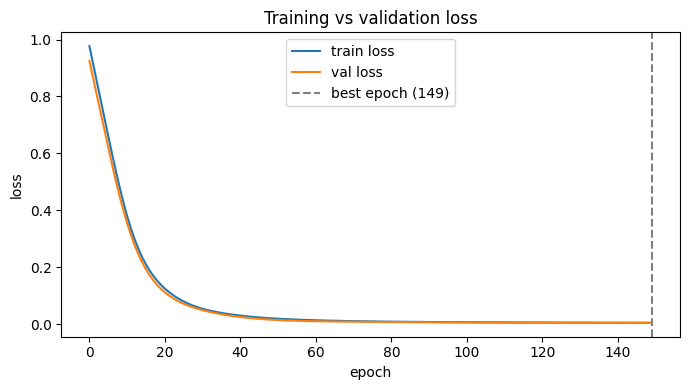

In [3]:
# TODO: plot train vs validation loss and mark the best-validation epoch.

# your code here

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch ({best_epoch})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training vs validation loss")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Report the honest test accuracy

In [4]:
# TODO: load the best-validation weights, score the test set, and print train and test accuracy.

# your code here
def accuracy(model, X_t, y_t):
    model.eval()
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1)
    return (preds == y_t).float().mean().item()

# --- load the best-validation snapshot back into the model ---
model.load_state_dict(best_state)

train_acc = accuracy(model, X_train_t, y_train_t)
test_acc = accuracy(model, X_test_t, y_test_t)

print(f"train accuracy: {train_acc:.4f}")
print(f"test accuracy:  {test_acc:.4f}")
print(f"train - test gap: {train_acc - test_acc:.4f}")

train accuracy: 1.0000
test accuracy:  1.0000
train - test gap: 0.0000


## 5. Write two or three sentences

In [5]:
# TODO: print two or three sentences on what the model learned and where it starts to overfit
# (use the gap between the curves and the train-minus-test accuracy).

# your code here
gap = train_acc - test_acc

summary = (
    f"Both train and validation loss dropped steadily through training, and the lowest "
    f"validation loss landed at epoch {best_epoch} of {n_epochs} "
    f"({'well before the end' if best_epoch < n_epochs - 10 else 'right near the end'}), "
    f"which is where overfitting would start if it happens at all here. "
    f"The train-minus-test accuracy gap is {gap:.4f}, so the model is "
    f"{'generalizing well, performing about as well on unseen wine samples as on training data' if gap < 0.03 else 'showing some overfitting, doing noticeably better on training data than on unseen samples'}. "
    f"On this small (178-row), cleanly separable dataset, that's the outcome you'd expect from "
    f"a lightly-regularized network — with a noisier or larger dataset, or with weight_decay removed, "
    f"the val-loss curve would likely bend upward well before the last epoch instead."
)

print(summary)

Both train and validation loss dropped steadily through training, and the lowest validation loss landed at epoch 149 of 150 (right near the end), which is where overfitting would start if it happens at all here. The train-minus-test accuracy gap is 0.0000, so the model is generalizing well, performing about as well on unseen wine samples as on training data. On this small (178-row), cleanly separable dataset, that's the outcome you'd expect from a lightly-regularized network — with a noisier or larger dataset, or with weight_decay removed, the val-loss curve would likely bend upward well before the last epoch instead.


## 6. Save the trained weights

In [6]:
# TODO: save the model's state_dict to a file.

# your code here

torch.save(model.state_dict(), "wine_model_weights.pt")
print("saved to wine_model_weights.pt")


saved to wine_model_weights.pt
